In [ ]:
!pip install -q --upgrade diffusers transformers accelerate insightface onnxruntime gdown
!pip install -q git+https://github.com/tencent-ailab/IP-Adapter.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 11.4 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 84.2 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 107.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 85.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 86.3 MB/s eta 0:00:00:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Downloading...
From: https://drive.google.com/uc?id=19gtC0VK7fGa9AA4LStcAH2fxn0hI_rDr
To: /kaggle/working/face.jpg
100%|██████████| 32.6k/32.6k [00:00<00:00, 52.1MB/s]


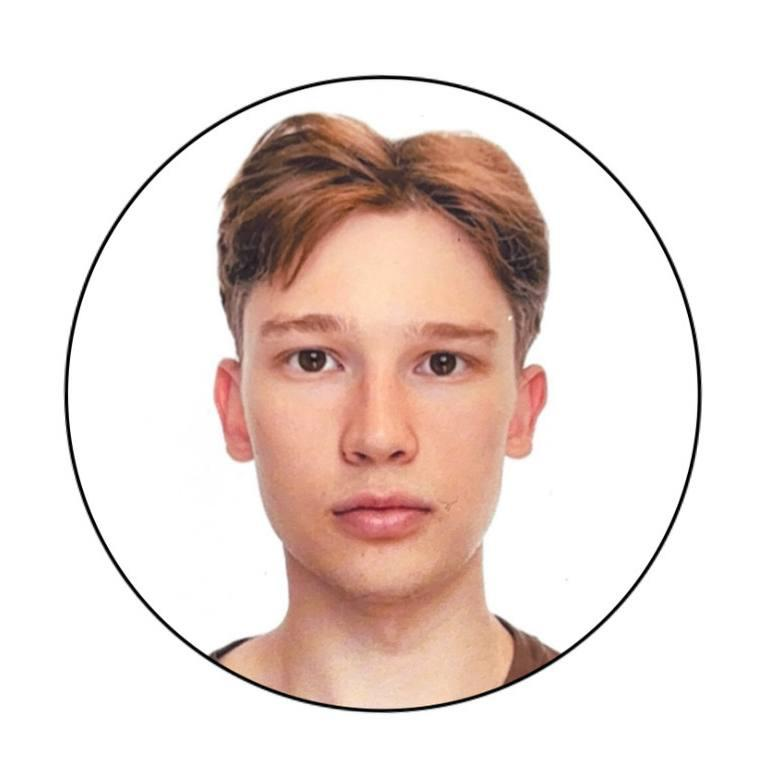

In [ ]:
import gdown
from IPython.display import display, Image

gdown.download(
    'https://drive.google.com/uc?id=19gtC0VK7fGa9AA4LStcAH2fxn0hI_rDr',
    'face.jpg',
    quiet=False
)

display(Image('face.jpg', width=300))

In [ ]:
import cv2
import torch
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis
from diffusers import StableDiffusionPipeline
from ip_adapter.ip_adapter_faceid import IPAdapterFaceID
from huggingface_hub import hf_hub_download

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

img = cv2.imread('face.jpg')
faces = app.get(img)
face_embeds = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 105905.95KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:148: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [ ]:
adapter_ckpt = hf_hub_download(
    repo_id='h94/IP-Adapter-FaceID',
    filename='ip-adapter-faceid_sd15.bin'
)

pipe = StableDiffusionPipeline.from_pretrained(
    'runwayml/stable-diffusion-v1-5',
    torch_dtype=torch.float16
).to('cuda')

ip_model = IPAdapterFaceID(pipe, adapter_ckpt, 'cuda')

ip-adapter-faceid_sd15.bin:   0%|          | 0.00/96.7M [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/models/lora.py:206: FutureWarning: `LoRALinearLayer` is deprecated and will be removed in version 1.0.0. Use of `LoRALinearLayer` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRALinearLayer", "1.0.0", deprecation_message)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

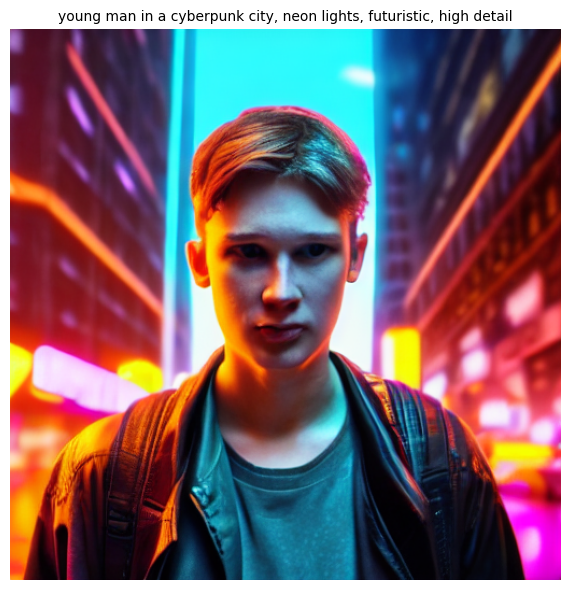

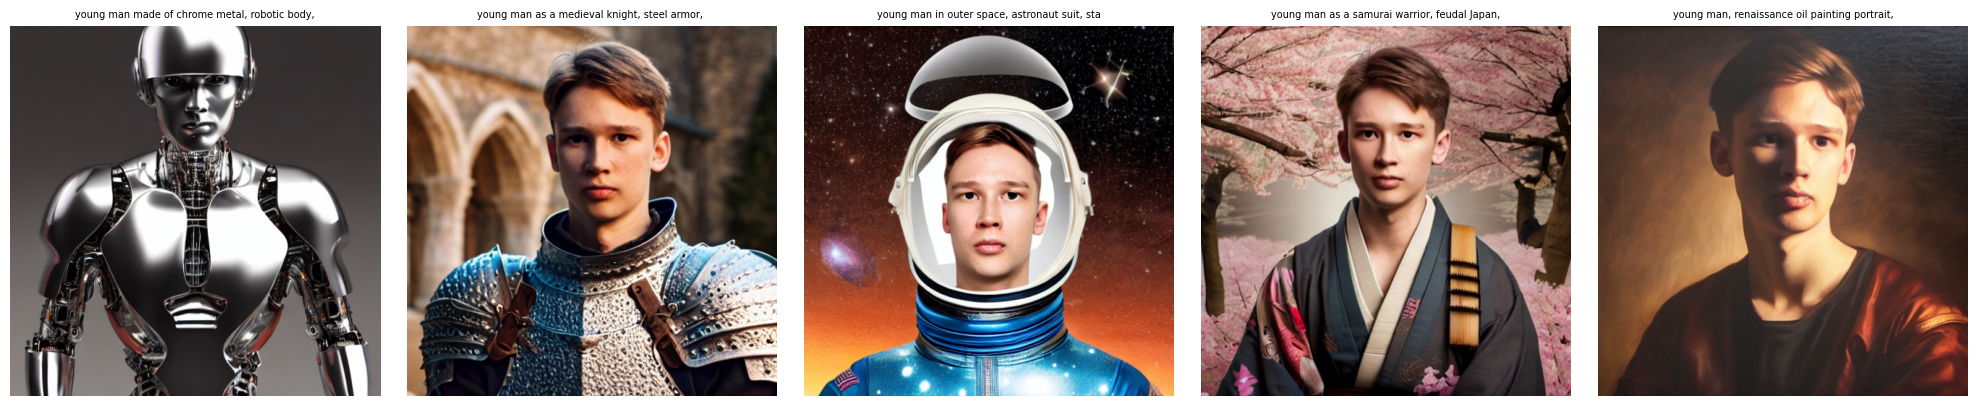

In [ ]:
SEED = 42
SCALE = 0.5

styled_prompts = [
    'young man in a cyberpunk city, neon lights, futuristic, high detail',
    'young man made of chrome metal, robotic body, sci-fi environment',
    'young man as a medieval knight, steel armor, castle background',
    'young man in outer space, astronaut suit, stars and nebula',
    'young man as a samurai warrior, feudal Japan, cherry blossom',
    'young man, renaissance oil painting portrait, dramatic lighting',
]

main_img = ip_model.generate(
    faceid_embeds=face_embeds,
    prompt=styled_prompts[0],
    negative_prompt='',
    scale=SCALE,
    num_samples=1,
    width=512, height=512,
    num_inference_steps=50,
    seed=SEED
)[0]

other_imgs = [
    ip_model.generate(
        faceid_embeds=face_embeds,
        prompt=p,
        negative_prompt='',
        scale=SCALE,
        num_samples=1,
        width=512, height=512,
        num_inference_steps=50,
        seed=SEED
    )[0]
    for p in styled_prompts[1:]
]

plt.figure(figsize=(6, 6))
plt.imshow(main_img)
plt.title(styled_prompts[0], fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, img, prompt in zip(axes, other_imgs, styled_prompts[1:]):
    ax.imshow(img)
    ax.set_title(prompt[:45], fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

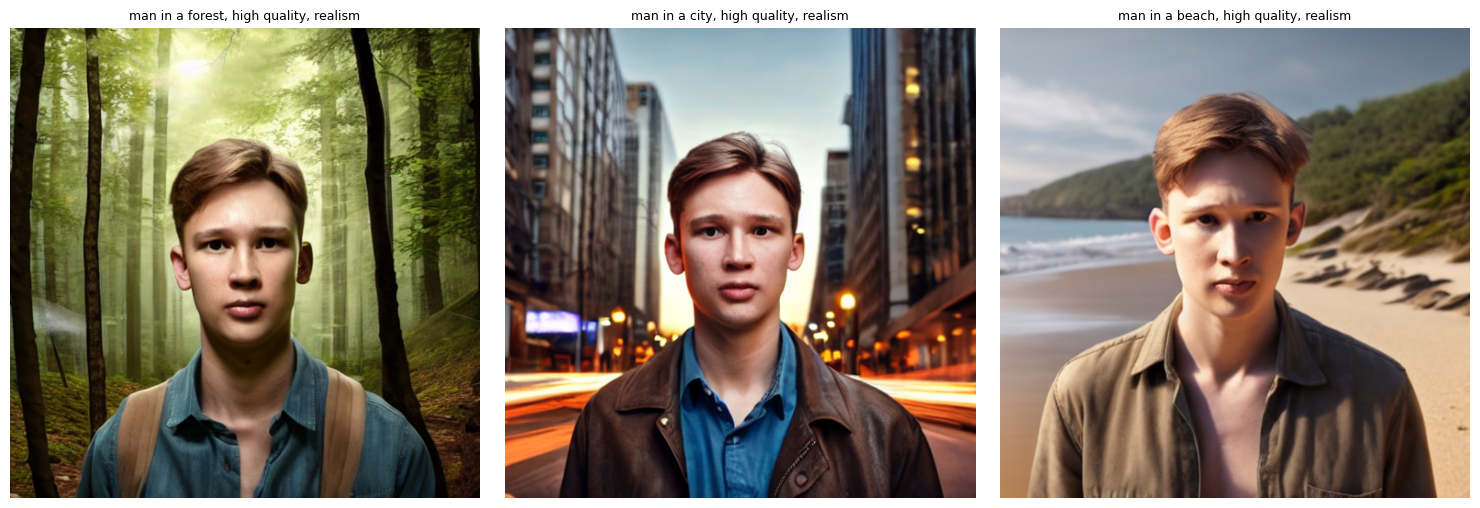

In [ ]:
required_prompts = [
    'man in a forest, high quality, realism',
    'man in a city, high quality, realism',
    'man in a beach, high quality, realism',
]

required_imgs = [
    ip_model.generate(
        faceid_embeds=face_embeds,
        prompt=p,
        negative_prompt='',
        scale=SCALE,
        num_samples=1,
        width=512, height=512,
        num_inference_steps=50,
        seed=SEED
    )[0]
    for p in required_prompts
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, prompt in zip(axes, required_imgs, required_prompts):
    ax.imshow(img)
    ax.set_title(prompt, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()